In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ankitayadav2005/customer-intelligence-system/marketing_campaign.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/ankitayadav2005/customer-intelligence-system/marketing_campaign.csv")

In [6]:
df.head()

,ID\tYear_Birth\tEducation\tMarital_Status\tIncome\tKidhome\tTeenhome\tDt_Customer\tRecency\tMntWines\tMntFruits\tMntMeatProducts\tMntFishProducts\tMntSweetProducts\tMntGoldProds\tNumDealsPurchases\tNumWebPurchases\tNumCatalogPurchases\tNumStorePurchases\tNumWebVisitsMonth\tAcceptedCmp3\tAcceptedCmp4\tAcceptedCmp5\tAcceptedCmp1\tAcceptedCmp2\tComplain\tZ_CostContact\tZ_Revenue\tResponse
0,5524\t1957\tGraduation\tSingle\t58138\t0\t0\t0...
1,2174\t1954\tGraduation\tSingle\t46344\t1\t1\t0...
2,4141\t1965\tGraduation\tTogether\t71613\t0\t0\...
3,6182\t1984\tGraduation\tTogether\t26646\t1\t0\...
4,5324\t1981\tPhD\tMarried\t58293\t1\t0\t19-01-2...


In [7]:
df.columns

Index(['ID\tYear_Birth\tEducation\tMarital_Status\tIncome\tKidhome\tTeenhome\tDt_Customer\tRecency\tMntWines\tMntFruits\tMntMeatProducts\tMntFishProducts\tMntSweetProducts\tMntGoldProds\tNumDealsPurchases\tNumWebPurchases\tNumCatalogPurchases\tNumStorePurchases\tNumWebVisitsMonth\tAcceptedCmp3\tAcceptedCmp4\tAcceptedCmp5\tAcceptedCmp1\tAcceptedCmp2\tComplain\tZ_CostContact\tZ_Revenue\tResponse'], dtype='object')

In [12]:
# Import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, silhouette_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

In [13]:
# Dataset Overview

df.shape

(2240, 1)

In [14]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 1 columns):
 #   Column                                                                                                                                                                                                                                                                                                                                                                    Non-Null Count  Dtype 
---  ------                                                                                                                                                                                                                                                                                                                                                                    --------------  ----- 
 0   ID	Year_Birth	Education	Marital_Status	Income	Kidhome	Teenhome	Dt_Customer	Recency	MntWines	MntFruits	MntMeat

,ID\tYear_Birth\tEducation\tMarital_Status\tIncome\tKidhome\tTeenhome\tDt_Customer\tRecency\tMntWines\tMntFruits\tMntMeatProducts\tMntFishProducts\tMntSweetProducts\tMntGoldProds\tNumDealsPurchases\tNumWebPurchases\tNumCatalogPurchases\tNumStorePurchases\tNumWebVisitsMonth\tAcceptedCmp3\tAcceptedCmp4\tAcceptedCmp5\tAcceptedCmp1\tAcceptedCmp2\tComplain\tZ_CostContact\tZ_Revenue\tResponse
count,2240
unique,2240
top,5524\t1957\tGraduation\tSingle\t58138\t0\t0\t0...
freq,1


In [15]:
# Check Missing Values

df.isnull().sum()df = pd.read_csv(
    "/kaggle/input/datasets/ankitayadav2005/customer-intelligence-system/marketing_campaign.csv",
    sep="\t"
)

ID\tYear_Birth\tEducation\tMarital_Status\tIncome\tKidhome\tTeenhome\tDt_Customer\tRecency\tMntWines\tMntFruits\tMntMeatProducts\tMntFishProducts\tMntSweetProducts\tMntGoldProds\tNumDealsPurchases\tNumWebPurchases\tNumCatalogPurchases\tNumStorePurchases\tNumWebVisitsMonth\tAcceptedCmp3\tAcceptedCmp4\tAcceptedCmp5\tAcceptedCmp1\tAcceptedCmp2\tComplain\tZ_CostContact\tZ_Revenue\tResponse    0
dtype: int64

In [17]:
df = pd.read_csv(
    "/kaggle/input/datasets/ankitayadav2005/customer-intelligence-system/marketing_campaign.csv",
    sep="\t"
)

In [18]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [19]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [20]:
# Feature Engineering

df["Age"] = 2026 - df["Year_Birth"]

df["Total_Spending"] = (
    df["MntWines"] +
    df["MntFruits"] +
    df["MntMeatProducts"] +
    df["MntFishProducts"] +
    df["MntSweetProducts"] +
    df["MntGoldProds"]
)

df["Total_Purchases"] = (
    df["NumDealsPurchases"] +
    df["NumWebPurchases"] +
    df["NumCatalogPurchases"] +
    df["NumStorePurchases"]
)

df["Children"] = df["Kidhome"] + df["Teenhome"]

df["Total_Accepted_Campaigns"] = (
    df["AcceptedCmp1"] +
    df["AcceptedCmp2"] +
    df["AcceptedCmp3"] +
    df["AcceptedCmp4"] +
    df["AcceptedCmp5"]
)

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Spending,Total_Purchases,Children,Total_Accepted_Campaigns
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,0,0,3,11,1,69,1617,25,0,0
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,0,0,3,11,0,72,27,6,2,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,0,0,3,11,0,61,776,21,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,0,0,3,11,0,42,53,8,1,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,0,0,3,11,0,45,422,19,1,0


In [21]:
# Feature Engineering

df["Age"] = 2026 - df["Year_Birth"]

df["Total_Spending"] = (
    df["MntWines"] +
    df["MntFruits"] +
    df["MntMeatProducts"] +
    df["MntFishProducts"] +
    df["MntSweetProducts"] +
    df["MntGoldProds"]
)

df["Total_Purchases"] = (
    df["NumDealsPurchases"] +
    df["NumWebPurchases"] +
    df["NumCatalogPurchases"] +
    df["NumStorePurchases"]
)

df["Children"] = df["Kidhome"] + df["Teenhome"]

df["Total_Accepted_Campaigns"] = (
    df["AcceptedCmp1"] +
    df["AcceptedCmp2"] +
    df["AcceptedCmp3"] +
    df["AcceptedCmp4"] +
    df["AcceptedCmp5"]
)

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Spending,Total_Purchases,Children,Total_Accepted_Campaigns
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,0,0,3,11,1,69,1617,25,0,0
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,0,0,3,11,0,72,27,6,2,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,0,0,3,11,0,61,776,21,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,0,0,3,11,0,42,53,8,1,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,0,0,3,11,0,45,422,19,1,0


In [22]:
# Drop Unnecessary Columns

df = df.drop(
    ["ID", "Year_Birth", "Dt_Customer", "Z_CostContact", "Z_Revenue"],
    axis=1
)

df.head()

,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Total_Spending,Total_Purchases,Children,Total_Accepted_Campaigns
0,Graduation,Single,58138.0,0,0,58,635,88,546,172,...,0,0,0,0,1,69,1617,25,0,0
1,Graduation,Single,46344.0,1,1,38,11,1,6,2,...,0,0,0,0,0,72,27,6,2,0
2,Graduation,Together,71613.0,0,0,26,426,49,127,111,...,0,0,0,0,0,61,776,21,0,0
3,Graduation,Together,26646.0,1,0,26,11,4,20,10,...,0,0,0,0,0,42,53,8,1,0
4,PhD,Married,58293.0,1,0,94,173,43,118,46,...,0,0,0,0,0,45,422,19,1,0


In [23]:
# Encode Categorical Columns

le = LabelEncoder()

df["Education"] = le.fit_transform(df["Education"])
df["Marital_Status"] = le.fit_transform(df["Marital_Status"])

df.head()

,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Total_Spending,Total_Purchases,Children,Total_Accepted_Campaigns
0,2,4,58138.0,0,0,58,635,88,546,172,...,0,0,0,0,1,69,1617,25,0,0
1,2,4,46344.0,1,1,38,11,1,6,2,...,0,0,0,0,0,72,27,6,2,0
2,2,5,71613.0,0,0,26,426,49,127,111,...,0,0,0,0,0,61,776,21,0,0
3,2,5,26646.0,1,0,26,11,4,20,10,...,0,0,0,0,0,42,53,8,1,0
4,4,3,58293.0,1,0,94,173,43,118,46,...,0,0,0,0,0,45,422,19,1,0


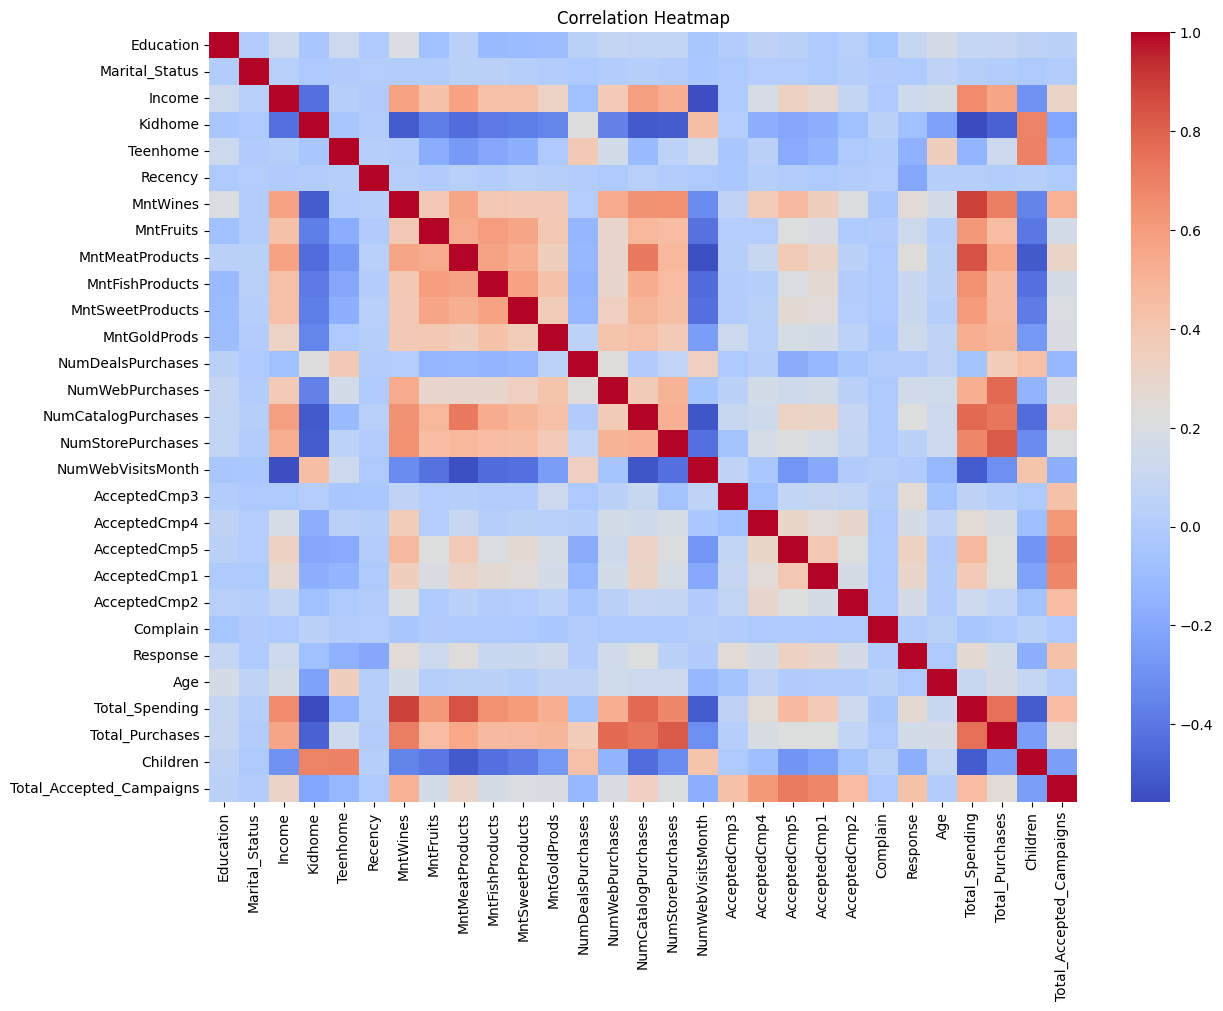

In [24]:
# EDA - Correlation Heatmap

plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

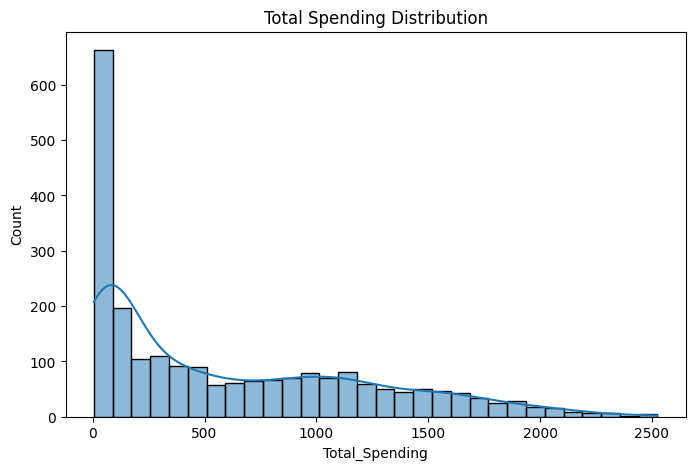

In [25]:
# EDA - Spending Distribution

plt.figure(figsize=(8, 5))
sns.histplot(df["Total_Spending"], bins=30, kde=True)
plt.title("Total Spending Distribution")
plt.show()

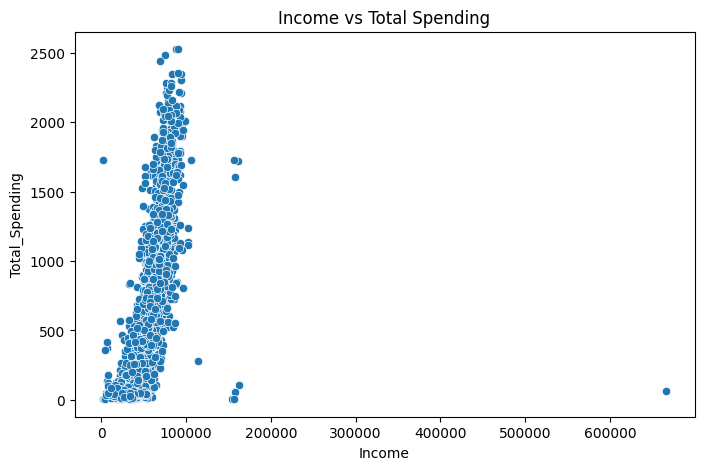

In [26]:
# EDA - Income vs Spending

plt.figure(figsize=(8, 5))
sns.scatterplot(x=df["Income"], y=df["Total_Spending"])
plt.title("Income vs Total Spending")
plt.show()

In [27]:
# Classification Setup

X = df.drop("Response", axis=1)
y = df["Response"]

In [28]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [29]:
# Feature Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [30]:
# Logistic Regression Model

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

print("Logistic Regression Report:")
print(classification_report(y_test, lr_pred))

Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.89      0.98      0.93       381
           1       0.70      0.28      0.40        67

    accuracy                           0.88       448
   macro avg       0.79      0.63      0.67       448
weighted avg       0.86      0.88      0.85       448



In [31]:
# Decision Tree Model

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Report:")
print(classification_report(y_test, dt_pred))

Decision Tree Report:
              precision    recall  f1-score   support

           0       0.89      0.90      0.89       381
           1       0.37      0.34      0.36        67

    accuracy                           0.81       448
   macro avg       0.63      0.62      0.62       448
weighted avg       0.81      0.81      0.81       448



In [32]:
# Random Forest Model

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Report:")
print(classification_report(y_test, rf_pred))

Random Forest Report:
              precision    recall  f1-score   support

           0       0.89      0.98      0.93       381
           1       0.75      0.31      0.44        67

    accuracy                           0.88       448
   macro avg       0.82      0.65      0.69       448
weighted avg       0.87      0.88      0.86       448



In [33]:
# XGBoost Model

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("XGBoost Report:")
print(classification_report(y_test, xgb_pred))

XGBoost Report:
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       381
           1       0.70      0.34      0.46        67

    accuracy                           0.88       448
   macro avg       0.80      0.66      0.70       448
weighted avg       0.86      0.88      0.86       448



In [34]:
# Model Comparison

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.875000,0.703704,0.283582,0.404255
1,Decision Tree,0.814732,0.370968,0.343284,0.356589
2,Random Forest,0.881696,0.750000,0.313433,0.442105
3,XGBoost,0.879464,0.696970,0.343284,0.460000


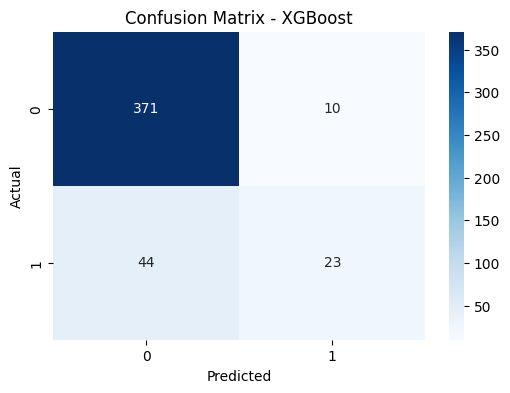

In [35]:
# Confusion Matrix - XGBoost

cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [36]:
# Feature Importance - Random Forest

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
5,Recency,0.091469
27,Total_Accepted_Campaigns,0.072753
2,Income,0.066901
6,MntWines,0.065398
24,Total_Spending,0.063102
8,MntMeatProducts,0.059403
11,MntGoldProds,0.047434
23,Age,0.044889
7,MntFruits,0.043330
10,MntSweetProducts,0.041198


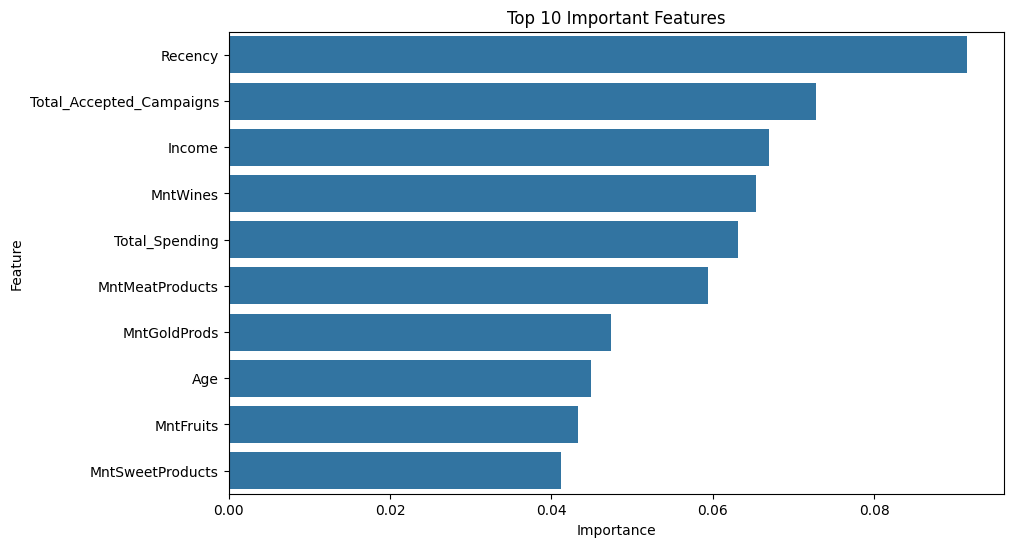

In [37]:
# Plot Top 10 Important Features

plt.figure(figsize=(10, 6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.head(10)
)
plt.title("Top 10 Important Features")
plt.show()

In [38]:
# Clustering Data Preparation

cluster_data = df.drop("Response", axis=1)

cluster_scaler = StandardScaler()

cluster_scaled = cluster_scaler.fit_transform(cluster_data)

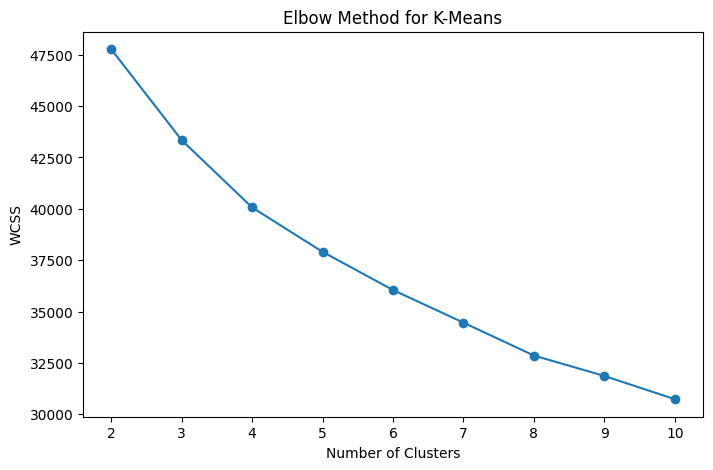

In [39]:
# Elbow Method for K-Means

wcss = []

for i in range(2, 11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    kmeans.fit(cluster_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), wcss, marker="o")
plt.title("Elbow Method for K-Means")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [40]:
# K-Means Clustering

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["KMeans_Cluster"] = kmeans.fit_predict(cluster_scaled)

df[["Income", "Total_Spending", "Total_Purchases", "KMeans_Cluster"]].head()

,Income,Total_Spending,Total_Purchases,KMeans_Cluster
0,58138.0,1617,25,1
1,46344.0,27,6,0
2,71613.0,776,21,1
3,26646.0,53,8,0
4,58293.0,422,19,2


In [41]:
# K-Means Silhouette Score

kmeans_score = silhouette_score(cluster_scaled, df["KMeans_Cluster"])

print("K-Means Silhouette Score:", kmeans_score)

K-Means Silhouette Score: 0.19174484519341836


In [42]:
# DBSCAN Clustering

dbscan = DBSCAN(
    eps=2,
    min_samples=5
)

df["DBSCAN_Cluster"] = dbscan.fit_predict(cluster_scaled)

df["DBSCAN_Cluster"].value_counts()

DBSCAN_Cluster
-1    1218
 1     384
 0     276
 3     210
 2      86
 7      35
 5      10
 4       9
 6       7
 8       5
Name: count, dtype: int64

In [43]:
# DBSCAN Silhouette Score

dbscan_labels = df["DBSCAN_Cluster"]

if len(set(dbscan_labels)) > 1:
    dbscan_score = silhouette_score(cluster_scaled, dbscan_labels)
    print("DBSCAN Silhouette Score:", dbscan_score)
else:
    print("DBSCAN created only one cluster. Silhouette score cannot be calculated.")

DBSCAN Silhouette Score: -0.020218075972544873


In [44]:
# PCA for Visualization

pca = PCA(n_components=2)

pca_data = pca.fit_transform(cluster_scaled)

df["PCA1"] = pca_data[:, 0]
df["PCA2"] = pca_data[:, 1]

df.head()

,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,Response,Age,Total_Spending,Total_Purchases,Children,Total_Accepted_Campaigns,KMeans_Cluster,DBSCAN_Cluster,PCA1,PCA2
0,2,4,58138.0,0,0,58,635,88,546,172,...,1,69,1617,25,0,0,1,-1,4.120282,0.419216
1,2,4,46344.0,1,1,38,11,1,6,2,...,0,72,27,6,2,0,0,0,-3.048047,0.261368
2,2,5,71613.0,0,0,26,426,49,127,111,...,0,61,776,21,0,0,1,-1,1.928221,-0.113545
3,2,5,26646.0,1,0,26,11,4,20,10,...,0,42,53,8,1,0,0,1,-2.774972,-1.394387
4,4,3,58293.0,1,0,94,173,43,118,46,...,0,45,422,19,1,0,2,-1,-0.369282,0.537377


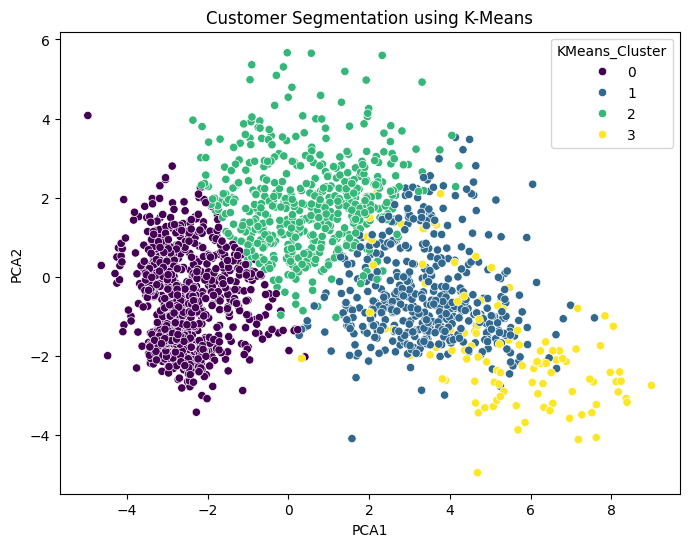

In [45]:
# K-Means Cluster Visualization

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x="PCA1",
    y="PCA2",
    hue="KMeans_Cluster",
    data=df,
    palette="viridis"
)
plt.title("Customer Segmentation using K-Means")
plt.show()

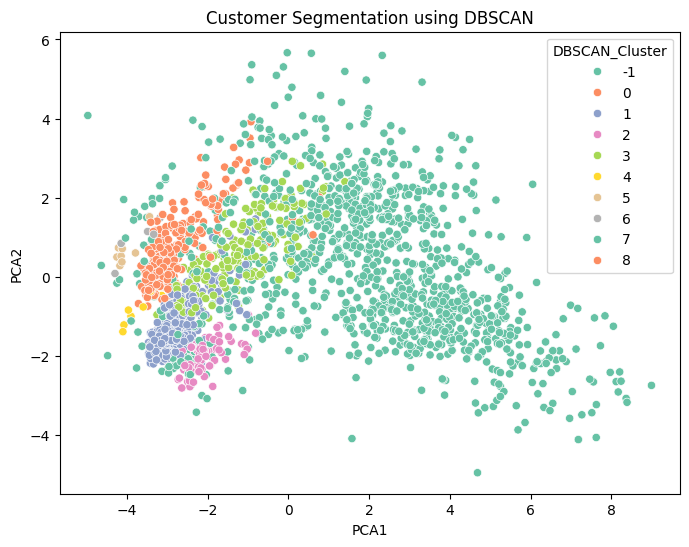

In [46]:
# DBSCAN Cluster Visualization

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x="PCA1",
    y="PCA2",
    hue="DBSCAN_Cluster",
    data=df,
    palette="Set2"
)
plt.title("Customer Segmentation using DBSCAN")
plt.show()

In [47]:
# Customer Segment Insights

segment_summary = df.groupby("KMeans_Cluster")[
    ["Income", "Total_Spending", "Total_Purchases", "Age", "Children"]
].mean()

segment_summary

,Income,Total_Spending,Total_Purchases,Age,Children
KMeans_Cluster,,,,,
0,35047.320700,94.939747,7.793003,54.501458,1.230321
1,74908.939394,1301.446465,20.737374,58.266667,0.222222
2,57146.451531,701.795918,20.937075,61.350340,1.219388
3,80213.542969,1581.429688,21.062500,55.601562,0.281250


In [48]:
# Final Business Insights

for cluster in segment_summary.index:
    print("Cluster:", cluster)
    print(segment_summary.loc[cluster])
    print("-" * 50)

Cluster: 0
Income             35047.320700
Total_Spending        94.939747
Total_Purchases        7.793003
Age                   54.501458
Children               1.230321
Name: 0, dtype: float64
--------------------------------------------------
Cluster: 1
Income             74908.939394
Total_Spending      1301.446465
Total_Purchases       20.737374
Age                   58.266667
Children               0.222222
Name: 1, dtype: float64
--------------------------------------------------
Cluster: 2
Income             57146.451531
Total_Spending       701.795918
Total_Purchases       20.937075
Age                   61.350340
Children               1.219388
Name: 2, dtype: float64
--------------------------------------------------
Cluster: 3
Income             80213.542969
Total_Spending      1581.429688
Total_Purchases       21.062500
Age                   55.601562
Children               0.281250
Name: 3, dtype: float64
--------------------------------------------------


In [49]:
# Final Conclusion

print("Customer Intelligence System successfully developed.")
print("Classification models were trained using Logistic Regression, Decision Tree, Random Forest, and XGBoost.")
print("Ensemble models Random Forest and XGBoost improved predictive performance.")
print("K-Means and DBSCAN were used for customer segmentation.")
print("PCA visualization helped understand customer groups.")
print("Business insights were generated from customer income, spending, purchases, and campaign response behavior.")

Customer Intelligence System successfully developed.
Classification models were trained using Logistic Regression, Decision Tree, Random Forest, and XGBoost.
Ensemble models Random Forest and XGBoost improved predictive performance.
K-Means and DBSCAN were used for customer segmentation.
PCA visualization helped understand customer groups.
Business insights were generated from customer income, spending, purchases, and campaign response behavior.


In [50]:
# Project Summary

print("Project Title: Customer Intelligence System")
print("Dataset Used: Customer Personality Analysis / Marketing Campaign Dataset")
print("Objective: To predict customer campaign response and segment customers based on behavior.")
print("Techniques Used: Classification, Ensemble Learning, K-Means, DBSCAN, PCA")
print("Best Classification Model: Check model comparison table for highest F1-score/accuracy.")
print("Customer Segments: Created using K-Means and DBSCAN clustering.")
print("Business Value: Helps identify high-value customers, low-engagement customers, and campaign-responsive customers.")

Project Title: Customer Intelligence System
Dataset Used: Customer Personality Analysis / Marketing Campaign Dataset
Objective: To predict customer campaign response and segment customers based on behavior.
Techniques Used: Classification, Ensemble Learning, K-Means, DBSCAN, PCA
Best Classification Model: Check model comparison table for highest F1-score/accuracy.
Customer Segments: Created using K-Means and DBSCAN clustering.
Business Value: Helps identify high-value customers, low-engagement customers, and campaign-responsive customers.
